Load and Compile All Datas

In [67]:
!pip install rpy2
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


R libraries

In [68]:
%%R
library(dplyr)
library(ggplot2)
library(lubridate)

Read all the files and concatenate them

In [69]:
import pandas as pd
from glob import glob

# Load all CSVs from the current directory
files = glob("Crime_Incidents_in_*.csv")

dfs = []
for f in files:
    df = pd.read_csv(f)
    dfs.append(df)

crime = pd.concat(dfs, ignore_index=True)

crime['REPORT_DAT'] = pd.to_datetime(crime['REPORT_DAT'], errors='coerce')
crime['YEAR'] = crime['REPORT_DAT'].dt.year
crime['HOUR'] = crime['REPORT_DAT'].dt.hour
crime['DAY'] = crime['REPORT_DAT'].dt.day
crime['DAY_OF_WEEK'] = crime['REPORT_DAT'].dt.day_name()

crime.head()


,X,Y,CCN,REPORT_DAT,SHIFT,METHOD,OFFENSE,BLOCK,XBLOCK,YBLOCK,...,LONGITUDE,BID,START_DATE,END_DATE,OBJECTID,OCTO_RECORD_ID,YEAR,HOUR,DAY,DAY_OF_WEEK
0,-77.031955,38.917558,18001310,2018-01-03 17:47:07+00:00,DAY,OTHERS,THEFT/OTHER,2000 - 2099 BLOCK OF 14TH STREET NW,397229.0,138854.0,...,-77.031952,NaN,2018/01/03 17:20:35+00,2018/01/03 17:47:06+00,406079101,NaN,2018,17,3,Wednesday
1,-77.026571,38.983284,18001603,2018-01-04 02:51:39+00:00,EVENING,OTHERS,THEFT F/AUTO,7700 - 7799 BLOCK OF GEORGIA AVENUE NW,397698.0,146150.0,...,-77.026569,NaN,2018/01/04 01:04:05+00,2018/01/04 01:47:55+00,406079102,NaN,2018,2,4,Thursday
2,-76.975712,38.900201,18001616,2018-01-04 04:21:19+00:00,MIDNIGHT,OTHERS,THEFT/OTHER,1900 - 1998 BLOCK OF H STREET NE,402107.0,136927.0,...,-76.975710,NaN,2018/01/03 17:59:24+00,2018/01/03 20:00:45+00,406079103,NaN,2018,4,4,Thursday
3,-76.947655,38.896660,18001724,2018-01-04 06:03:43+00:00,MIDNIGHT,OTHERS,SEX ABUSE,4000 - 4121 BLOCK OF MINNESOTA AVENUE NE,404541.0,136535.0,...,-76.947653,NaN,2017/12/30 01:00:01+00,2017/12/30 17:00:56+00,406079104,NaN,2018,6,4,Thursday
4,-76.947655,38.896660,18001724,2018-01-04 06:03:43+00:00,MIDNIGHT,OTHERS,SEX ABUSE,4000 - 4121 BLOCK OF MINNESOTA AVENUE NE,404541.0,136535.0,...,-76.947653,NaN,2017/12/30 01:00:01+00,2017/12/30 17:00:56+00,406079105,NaN,2018,6,4,Thursday


Import Crime once Defined into R From Python

In [70]:
%R -i crime


/usr/local/lib/python3.12/dist-packages/rpy2/robjects/pandas2ri.py:65: UserWarning: Error while trying to convert the column "BID". Fall back to string conversion. The error is: Series can only be of one type, or None (and here we have <class 'float'> and <class 'str'>). If happening with a pandas DataFrame the method infer_objects() will normalize data types before conversion.
  warnings.warn('Error while trying to convert '


In [71]:
crime['YEAR'].value_counts().sort_index()

,count
YEAR,
2008,34307
2009,31356
2010,31692
2011,33215
2012,35270
2013,35874
2014,38404
2015,37176
2016,37199


In [72]:
len(crime)

562317

In [73]:
crime.shape

(562317, 29)

Python Visualization Insight 1

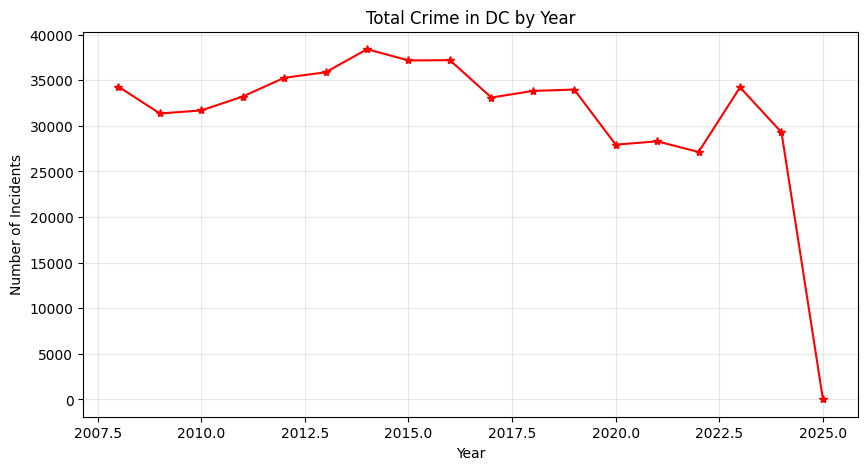

In [78]:
import matplotlib.pyplot as plt

yearly = crime.groupby('YEAR').size().reset_index(name='COUNT')

plt.figure(figsize=(10,5))
plt.plot(yearly['YEAR'], yearly['COUNT'], marker='*', color = "red")
plt.title("Total Crime in DC by Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.grid(True, alpha=0.3)
plt.show()



(`geom_line()`). 

(`geom_point()`). 



In addition: Warning message:
 2298 failed to parse. 


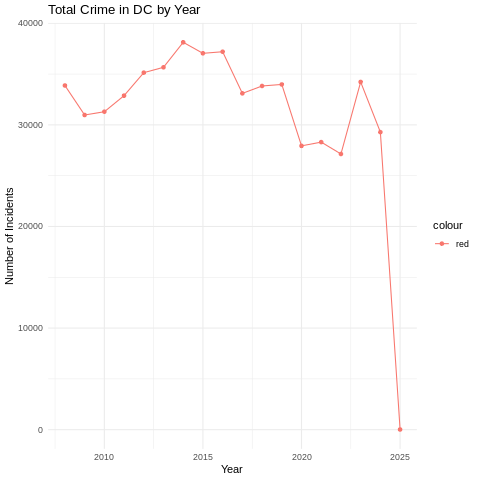

In [87]:
%%R
library(dplyr)
library(ggplot2)
library(lubridate)

# Convert Python dataframe "crime" into R dataframe "crime_r"
crime_r <- as.data.frame(crime)

crime_r$REPORT_DAT <- ymd_hms(crime_r$REPORT_DAT)

# Take the years off
crime_r <- crime_r %>%
  mutate(YEAR = year(REPORT_DAT))

# Count by year
yearly_r <- crime_r %>%
  count(YEAR, name = "COUNT")

# Line chart
ggplot(yearly_r, aes(x = YEAR, y = COUNT, color = "red")) +
  geom_line() +
  geom_point() +
  labs(
    title = "Total Crime in DC by Year",
    x = "Year",
    y = "Number of Incidents"
  ) +
  theme_minimal()



The Most Crime Happened in 2014 while the Lowest seems to be in 2025.

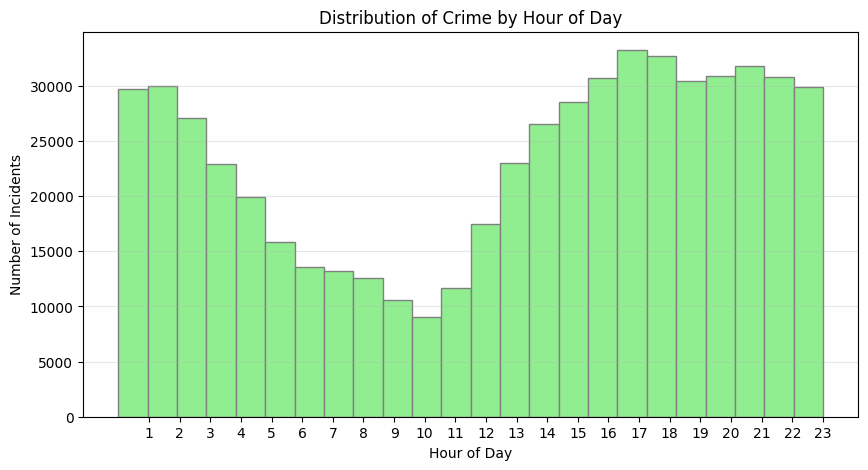

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(crime['HOUR'], bins=24, color='lightgreen', edgecolor='grey')
plt.title("Distribution of Crime by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Incidents")
plt.xticks(range(1,24))
plt.grid(axis='y', alpha=0.3)
plt.show()


In addition: Warning message:
 2298 failed to parse. 


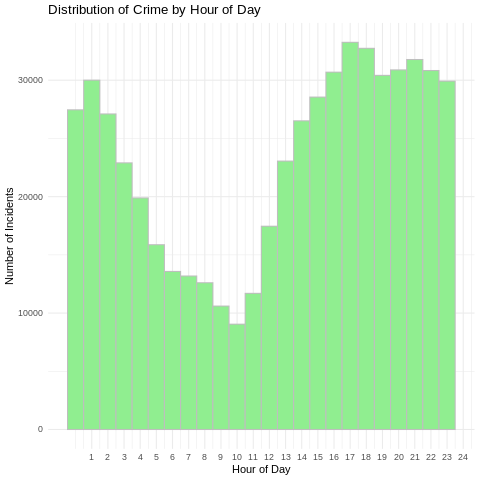

In [77]:
%%R
library(ggplot2)
library(lubridate)
library(dplyr)

crime_r <- as.data.frame(crime)

# Parse Data
crime_r$REPORT_DAT <- ymd_hms(crime_r$REPORT_DAT)

# Extract hour
crime_r <- crime_r %>% mutate(HOUR = hour(REPORT_DAT))

ggplot(crime_r, aes(x = HOUR)) +
  geom_histogram(binwidth = 1, fill = "lightgreen", color = "grey") +
  labs(
    title = "Distribution of Crime by Hour of Day",
    x = "Hour of Day",
    y = "Number of Incidents"
  ) +
  scale_x_continuous(breaks = 1:24) +
  theme_minimal()


The most crime happened around 5 PM and the least happened around 10 AM.

---


